<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/08.Seq2seq_and_Attention_Mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [ ]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
import os

repository_name = 'nlp2026'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd nlp2026

In [1]:
%matplotlib inline

# Seq2eq with Attention Mechanism

* 이 자료는 다음 자료를 참고했습니다.<br>
  * [Sean Robertson](https://github.com/spro/practical-pytorch)
* NMT 태스크(불어 → 영어)에 적용


In [2]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import string
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 데이터 파일 로딩

* 데이터셋: nlp2026 repository 내 `data` folder에 `eng-fra.txt`와 `names` subfolder에 미리 저장되어 있음

In [3]:
SOS_token = 0
EOS_token = 1

# 단어 집합과 단어 인덱스 간의 매핑을 관리하는 Helper 클래스
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {} # key: 각 단어명, value: 각 단어 인덱스
        self.word2count = {} # key: 각 단어명, value: 각 단어 개수
        self.index2word = {0: "SOS", 1: "EOS"} # key: 각 단어 인덱스, value: 각 단어명
        self.n_words = 2  # SOS 와 EOS 포함 # 총 단어 개수

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

파일은 모두 유니 코드로 되어있어 간단하게 하기 위해 유니 코드 문자를 ASCII로 변환하고, 모든 문자를 소문자로 만들고, 대부분의 구두점을
지워준다.




In [4]:
# 유니 코드 문자열을 일반 ASCII로 변환
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# 텍스트 정규화: 소문자, 다듬기, 그리고 문자가 아닌 문자 제거
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

- 데이터 파일을 읽기위해 파일을 줄 단위로 나누고, 각 줄을 다시 두 개씩 묶는다.
- 파일은 모두 영어 → 다른 언어 순으로 되어있다.
- 다른 언어에서 영어로 번역하려면 `reverse` 플래그를 추가하여 쌍을 반전시킨다.

In [5]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # 파일을 읽고 줄로 분리
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')

    # 모든 줄을 쌍으로 분리하고 정규화
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Lang 인스턴스 생성(`reverse` 플래그가 있으면 쌍을 뒤집는다)
    if reverse:  
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

- 간단한 실습을 위해 최대 길이 10 단어(문장 마침표 부호 포함) 이내의 짧은 문장만 선택
- "I am" 또는 "He is" 등의 형태로 번역되는 문장으로 필터링한다(이전에 아포스트로피는 대체 됨)

In [6]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

데이터 준비를 위한 전체 과정:
1) 텍스트 파일을 읽고 줄로 분리하고, 줄을 쌍으로 분리
2) 텍스트를 정규화 하고 길이와 내용으로 필터링
3) 쌍을 이룬 문장들로 단어 리스트를 생성

In [7]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 10599 sentence pairs
Counting words...
Counted words:
fra 4345
eng 2803
['tu es celle qui m a formee .', 'you re the one who trained me .']


## Seq2Seq 모델

### 인코더

![](images/encoder-network.png)

In [8]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

### 디코더

#### 간단한 디코더

- 가장 간단한 Seq2Seq 디코더로서, 인코더의 마지막 출력만을 이용한다.
- 이 마지막 출력은 전체 시퀀스에서 문맥을 인코드하기 때문에 *문맥 벡터(context vector)* 로 불린다.
- 이 문맥 벡터는 디코더의 초기 은닉 상태로 사용된다.
- 초기 입력 토큰은 문장 시작 ``<SOS>`` 토큰이고,
- 첫 은닉 상태는 문맥 벡터(인코더의 마지막 은닉 상태)다.

![](images/encoder-network.png)





In [9]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        output = self.embedding(input).view(1, 1, -1)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

#### 이 모델의 훈련 결과를 관찰하면 좋겠으나, 시간 절약을 위해 여기서 바로 Attention 메커니즘을 도입한다.




#### Attention 디코더

![](images/attention-decoder-network.png)




In [10]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1, max_length=MAX_LENGTH):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = max_length

        self.embedding = nn.Embedding(self.output_size, self.hidden_size)
        self.attn = nn.Linear(self.hidden_size * 2, self.max_length)
        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        attn_weights = F.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)
        attn_applied = torch.bmm(attn_weights.unsqueeze(0),
                                 encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = F.relu(output)
        output, hidden = self.gru(output, hidden)

        output = F.log_softmax(self.out(output[0]), dim=1)
        return output, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

**[Note]** 입력 문장의 길이로 인한 제약을 피하는 방법이 필요하면 [Luong et al. (2015)](https://arxiv.org/abs/1508.04025)의 Local Attention을 참조하라.

## 학습

### 학습 데이터 준비

In [11]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]


def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

### 모델 학습

- 학습을 위해서 인코더에 입력 문장을 넣고 모든 출력과 최신 은닉 상태를 추적한다.
- 그런 다음, 디코더에 첫 번째 입력으로 ``<SOS>`` 토큰과 인코더의 마지막 은닉 상태가 첫 번째 은닉 상태로 제공된다.
- **Teacher forcing**은 다음 입력으로 디코더의 예측을 사용하는 대신 실제 목표 출력을 다음 입력으로 사용하는 방법이다.
  - Teacher forcing을 사용하면 수렴이 빨리되지만 [학습된 네트워크가 잘못 사용되면, 불안정성해질 수 있다.](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.378.4095&rep=rep1&type=pdf)
  - Teacher-forcing이 사용된 신경망 출력이 정확한 번역과는 거리가 멀다는 것을 볼 수 있다.
  - 직관적 설명: Teacher가 처음 몇 단어를 알려주면, 생성할 단어의 의미를 "선택" 할 수 있지만, 번역에서 처음으로 문장을 만드는 법은 잘 배우지 못한다.
- PyTorch의 autograd가 제공하는 자유도 덕분에 간단한 If 문으로 Teacher Forcing의 정도를 조절할 수 있다.
- ``teacher_forcing_ratio`` 를 사용한다.



In [12]:
teacher_forcing_ratio = 0.5

def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, max_length=MAX_LENGTH):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    loss = 0

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing 포함: 목표를 다음 입력으로 전달
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]  # Teacher forcing

    else:
        # Teacher forcing 미포함: 자신의 예측을 다음 입력으로 사용
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()  # 입력으로 사용할 부분을 히스토리에서 분리

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [13]:
# 현재 시간과 진행률(%)을 고려해 경과된 시간과 남은 예상 시간을 출력하는 헬퍼 함수
import time
import math


def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)


def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

### 결과 시각화

In [14]:
import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np


def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # 주기적인 간격에 이 locator가 tick을 설정
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

#### 전체 학습 과정:

In [15]:
def trainIters(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.01):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # print_every 마다 초기화
    plot_loss_total = 0  # plot_every 마다 초기화

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    training_pairs = [tensorsFromPair(random.choice(pairs))
                      for i in range(n_iters)]
    criterion = nn.NLLLoss()

    for iter in range(1, n_iters + 1):
        training_pair = training_pairs[iter - 1]
        input_tensor = training_pair[0]
        target_tensor = training_pair[1]

        loss = train(input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg))

        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

## 평가

- 평가(test)는 대부분 학습과 동일하지만 목표가 없으므로 각 단계마다 디코더의 예측을 되돌려 전달한다.
- 단어를 예측할 때마다 그 단어를 출력 문자열에 추가한다.
- 만약 EOS 토큰을 예측하면 거기에서 멈춘다.
- 나중에 시각화를 위해서 디코더의 Attention 출력을 저장한다.

In [16]:
def evaluate(encoder, decoder, sentence, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size()[0]
        encoder_hidden = encoder.initHidden()

        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei],
                                                     encoder_hidden)
            encoder_outputs[ei] += encoder_output[0, 0]

        decoder_input = torch.tensor([[SOS_token]], device=device)  # SOS

        decoder_hidden = encoder_hidden

        decoded_words = []
        decoder_attentions = torch.zeros(max_length, max_length)

        for di in range(max_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            decoder_attentions[di] = decoder_attention.data
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token: # topi.item()은 topi[0,0]과 같은 결과를 반환함.
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])

            decoder_input = topi.squeeze().detach()

        return decoded_words, decoder_attentions[:di + 1]

Training 데이터셋에 있는 임의의 문장을 평가하고 입력, 목표 및 출력을 출력하여 주관적인 품질 판단을 내릴 수 있다:

In [17]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, attentions = evaluate(encoder, decoder, pair[0])
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

- 반복 수를 75000으로 설정하여 모델을 훈련한다. print_every=5000으로 설정하여 5000회마다 평균 손실을 출력한다.
- PC에서 약 20분 정도 소요된다. 실습을 위해서는 1/10 정도로 줄이는 것이 좋다.

In [25]:
hidden_size = 256
encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
attn_decoder1 = AttnDecoderRNN(hidden_size, output_lang.n_words, dropout_p=0.1).to(device)

trainIters(encoder1, attn_decoder1, 7500, print_every=500)

0m 7s (- 1m 43s) (500 6%) 3.6552
0m 14s (- 1m 37s) (1000 13%) 3.2074
0m 22s (- 1m 30s) (1500 20%) 2.9352
0m 30s (- 1m 24s) (2000 26%) 2.8211
0m 38s (- 1m 16s) (2500 33%) 2.7765
0m 46s (- 1m 9s) (3000 40%) 2.7605
0m 53s (- 1m 1s) (3500 46%) 2.6926
1m 1s (- 0m 53s) (4000 53%) 2.5956
1m 9s (- 0m 46s) (4500 60%) 2.4784
1m 16s (- 0m 38s) (5000 66%) 2.5279
1m 24s (- 0m 30s) (5500 73%) 2.4317
1m 31s (- 0m 22s) (6000 80%) 2.3917
1m 39s (- 0m 15s) (6500 86%) 2.3688
1m 47s (- 0m 7s) (7000 93%) 2.3684
1m 55s (- 0m 0s) (7500 100%) 2.2586


In [26]:
evaluateRandomly(encoder1, attn_decoder1)

> vous etes endurantes .
= you re resilient .
< you re safe . <EOS>

> je ne suis pas ici pour affaires .
= i m not here on business .
< i m not your to . <EOS>

> je suis ivre .
= i m drunk .
< i m busy . <EOS>

> vous etes vraiment tres bons .
= you are really very good .
< you are very very good . <EOS>

> il exerce sur elle du chantage .
= she is being blackmailed by him .
< he is a a of his . <EOS>

> nous ne sommes que des enfants .
= we re just children .
< we re not sure . <EOS>

> nous sommes certains .
= we re certain .
< we re all . <EOS>

> tu n es pas grosse .
= you re not fat .
< you re not dead . <EOS>

> vous etes bon cuisinier n est ce pas ?
= you are a good cook aren t you ?
< you re very aren t you ? ? ? ?

> il etudie l agronomie .
= he is studying agriculture .
< he is a a . . <EOS>



### Attention 시각화

- Attention 메커니즘의 유용한 속성 중 하나는 출력의 높은 해석가능성이다.
- 입력 시퀀스의 특정 인코더 출력에 가중치를 부여하는 데 사용되므로, 각 시간 단계에서 네트워크가 가장 집중되는 위치를 파악할 수 있다.
- Attention 출력을 행렬로 표시하기 위해 `plt.matshow(attentions)` 를 사용한다.
  - 열: 입력 단계
  - 행: 출력 단계

In [27]:
output_words, attentions = evaluate(
    encoder1, attn_decoder1, "je suis trop froid .")
plt.matshow(attentions.numpy())

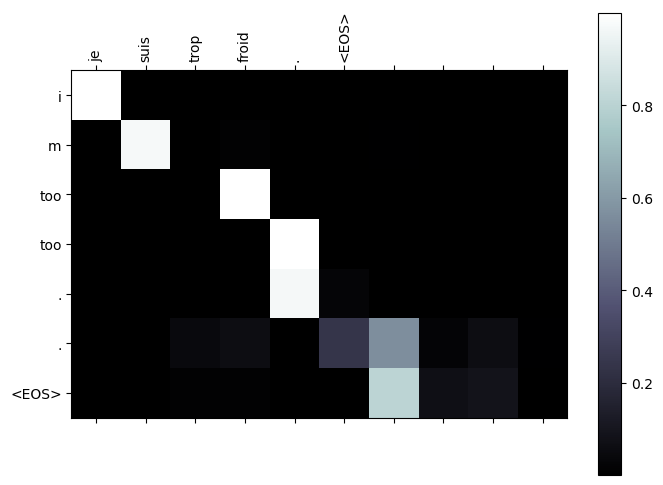

In [28]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(8, 6))
attn_data = attentions.cpu().numpy()
cax = ax.matshow(attn_data, cmap='bone')
fig.colorbar(cax, ax=ax)

input_tokens = "je suis trop froid .".split(' ')
ax.set_xticks(range(len(input_tokens) + 1))
ax.set_xticklabels(input_tokens + ['<EOS>'], rotation=90)
ax.set_yticks(range(len(output_words)))
ax.set_yticklabels(output_words)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
display(fig)
plt.close(fig)